# ARB Airdrop: Post-claim Activity Charts

## tl;dr

- **82.8%** of validated claim recipients initiated at least one qualifying successful transaction within 24 hours; **90.9%** did so within seven days.
- **64.9%** had their first qualifying activity within one hour, while **9.1%** had no qualifying activity during the first seven days.
- Seven-day participation was similar across claim-size segments, but average transactions per active recipient increased from **4.33** in the lowest segment to **12.05** in the highest.
- Recipients with 11 or more qualifying transactions represented **11.7%** of the cohort and **66.1%** of seven-day transaction rows.

These are address-activity measures, not proof of retained human usage, protocol engagement, token retention, or sales.

## Context & Methods

This companion notebook turns the validated claim-grain post-claim activity output into three portfolio-ready figures. It reads small, versioned JSON artifacts in `data/`; it does not query BigQuery.

### Key Assumptions

- **Cohort grain:** one validated `HasClaimed` event and unique recipient per row, 583,137 rows in total.
- **Activity:** a successful top-level Arbitrum transaction initiated by the validated claim recipient and ordered after the exact claim transaction.
- **Observation windows:** elapsed half-open windows of 24 hours and seven days after each exact claim timestamp.
- **Claim-size groups:** the same cutpoints as the early-outflow figures: 875, 1,250, and 2,250 ARB.
- **Interpretation:** automated wallets, contracts, and repeated actions can contribute activity. The metrics do not identify people or measure protocol-specific engagement.

The visual specification is recorded in `reports/post_claim_activity_chart_contract.md`.

In [1]:
from pathlib import Path
import json

import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import Image, display


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "data" / "post_claim_activity_chart_data.json").exists():
            return candidate
    raise FileNotFoundError(
        "Could not locate data/post_claim_activity_chart_data.json"
    )


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
DATA_PATH = PROJECT_ROOT / "data" / "post_claim_activity_chart_data.json"
QA_PATH = PROJECT_ROOT / "data" / "post_claim_activity_chart_data_qa.json"
FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

print("Project root: <repository root>")
print(f"Data source: {DATA_PATH.relative_to(PROJECT_ROOT)}")

Project root: <repository root>
Data source: data\post_claim_activity_chart_data.json


## Data

The input contains two elapsed-window rows, four claim-size segments, six mutually exclusive first-activity timing buckets, and five mutually exclusive seven-day intensity buckets. Every check in the accompanying QA artifact must pass before any chart is rendered.

In [2]:
with DATA_PATH.open(encoding="utf-8") as file:
    chart_data = json.load(file)

with QA_PATH.open(encoding="utf-8") as file:
    chart_qa = json.load(file)

assert all(chart_qa["checks"].values()), "Chart-data QA contains a failed check."

window_df = pd.DataFrame(chart_data["window_summary"]).sort_values("window_order")
segment_df = pd.DataFrame(chart_data["claim_size_segments"]).sort_values(
    "segment_order"
)
timing_df = pd.DataFrame(chart_data["first_activity_timing"]).sort_values(
    "bucket_order"
)
intensity_df = pd.DataFrame(chart_data["activity_intensity_7d"]).sort_values(
    "bucket_order"
)

assert len(window_df) == 2
assert len(segment_df) == 4
assert len(timing_df) == 6
assert len(intensity_df) == 5
assert segment_df["recipient_count"].sum() == chart_qa["claim_rows"]
assert timing_df["recipient_count"].sum() == chart_qa["claim_rows"]
assert intensity_df["recipient_count"].sum() == chart_qa["claim_rows"]
assert intensity_df["successful_transaction_rows"].sum() == 3_872_570

pd.DataFrame(
    {
        "dataset": [
            "Elapsed windows",
            "Claim-size segments",
            "Timing buckets",
            "Intensity buckets",
        ],
        "rows": [
            len(window_df),
            len(segment_df),
            len(timing_df),
            len(intensity_df),
        ],
        "recipient_total": [
            int(window_df["recipient_count"].max()),
            int(segment_df["recipient_count"].sum()),
            int(timing_df["recipient_count"].sum()),
            int(intensity_df["recipient_count"].sum()),
        ],
    }
)

,dataset,rows,recipient_total
0,Elapsed windows,2,583137
1,Claim-size segments,4,583137
2,Timing buckets,6,583137
3,Intensity buckets,5,583137


## Results

### 1. First post-claim activity timing

The first chart uses mutually exclusive buckets across the complete cohort, including recipients with no qualifying activity during the first seven days.

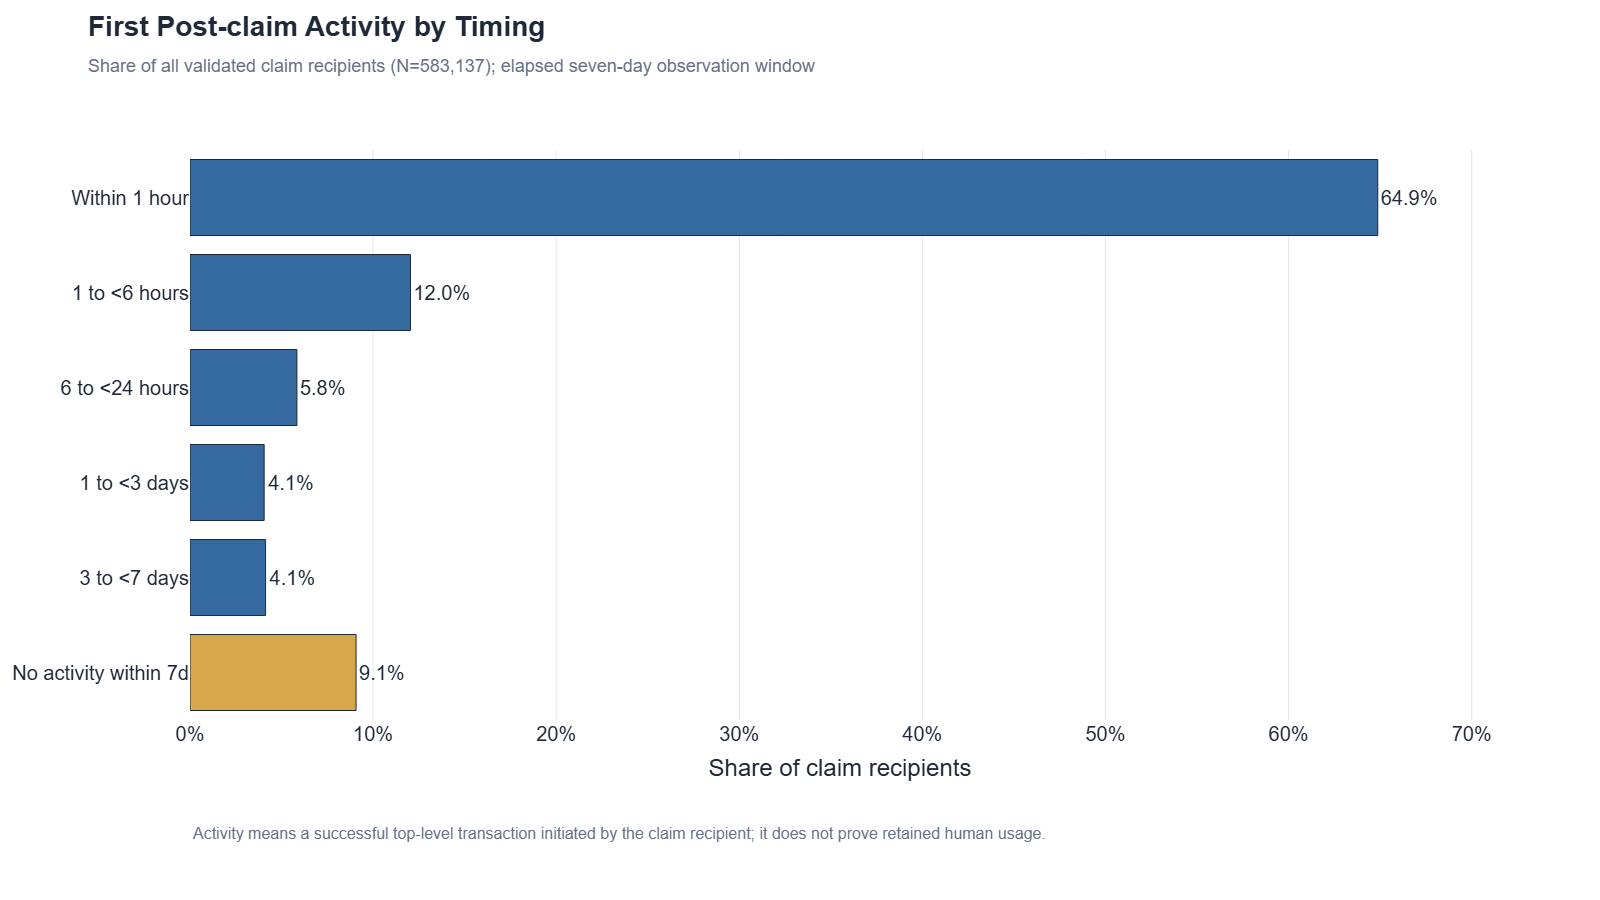

In [3]:
COLORS = {
    "blue": "#356AA0",
    "blue_light": "#A9C4E2",
    "gold": "#D6A84B",
    "gold_light": "#F3E3B6",
    "ink": "#1F2937",
    "muted": "#667085",
    "grid": "#E5E7EB",
    "white": "#FFFFFF",
}


def apply_base_layout(
    fig,
    title,
    subtitle,
    width=1600,
    height=900,
    bottom_note=None,
    margins=None,
):
    if margins is None:
        margins = dict(l=185, r=110, t=150, b=180 if bottom_note else 95)
    fig.update_layout(
        width=width,
        height=height,
        paper_bgcolor=COLORS["white"],
        plot_bgcolor=COLORS["white"],
        font=dict(family="Arial", size=20, color=COLORS["ink"]),
        title=dict(
            text=(
                f"<b>{title}</b><br>"
                f"<span style='font-size:18px;color:{COLORS['muted']}'>"
                f"{subtitle}</span>"
            ),
            x=0.055,
            xanchor="left",
            y=0.96,
            yanchor="top",
        ),
        margin=margins,
        showlegend=False,
    )
    if bottom_note:
        fig.add_annotation(
            x=0,
            y=-0.18,
            xref="paper",
            yref="paper",
            xanchor="left",
            yanchor="top",
            showarrow=False,
            align="left",
            font=dict(size=16, color=COLORS["muted"]),
            text=bottom_note,
        )
    return fig


def export_and_display(fig, stem):
    png_path = FIGURES_DIR / f"{stem}.png"
    svg_path = FIGURES_DIR / f"{stem}.svg"
    fig.write_image(png_path, scale=1)
    fig.write_image(svg_path)
    display(Image(data=png_path.read_bytes(), width=1100))
    return png_path, svg_path


timing_colors = [COLORS["blue"]] * 5 + [COLORS["gold"]]
timing_fig = go.Figure(
    go.Bar(
        x=timing_df["recipient_share"],
        y=timing_df["timing_bucket"],
        orientation="h",
        marker=dict(color=timing_colors, line=dict(color=COLORS["ink"], width=1)),
        text=timing_df["recipient_share"].map(lambda value: f"{value:.1%}"),
        textposition="outside",
        cliponaxis=False,
        hovertemplate="%{y}<br>%{x:.1%} of recipients<extra></extra>",
    )
)
apply_base_layout(
    timing_fig,
    "First Post-claim Activity by Timing",
    "Share of all validated claim recipients (N=583,137); elapsed seven-day observation window",
    bottom_note=(
        "Activity means a successful top-level transaction initiated by the claim recipient; "
        "it does not prove retained human usage."
    ),
)
timing_fig.update_xaxes(
    range=[0, 0.71],
    tickformat=".0%",
    title="Share of claim recipients",
    showgrid=True,
    gridcolor=COLORS["grid"],
    zeroline=False,
)
timing_fig.update_yaxes(
    title=None,
    autorange="reversed",
    showgrid=False,
    automargin=True,
)
_ = export_and_display(timing_fig, "04_first_post_claim_activity_timing")

### 2. Activity breadth and depth by claim size

The second figure keeps participation and transaction depth in separate panels. The same four claim-size groups are used in the early-outflow analysis.

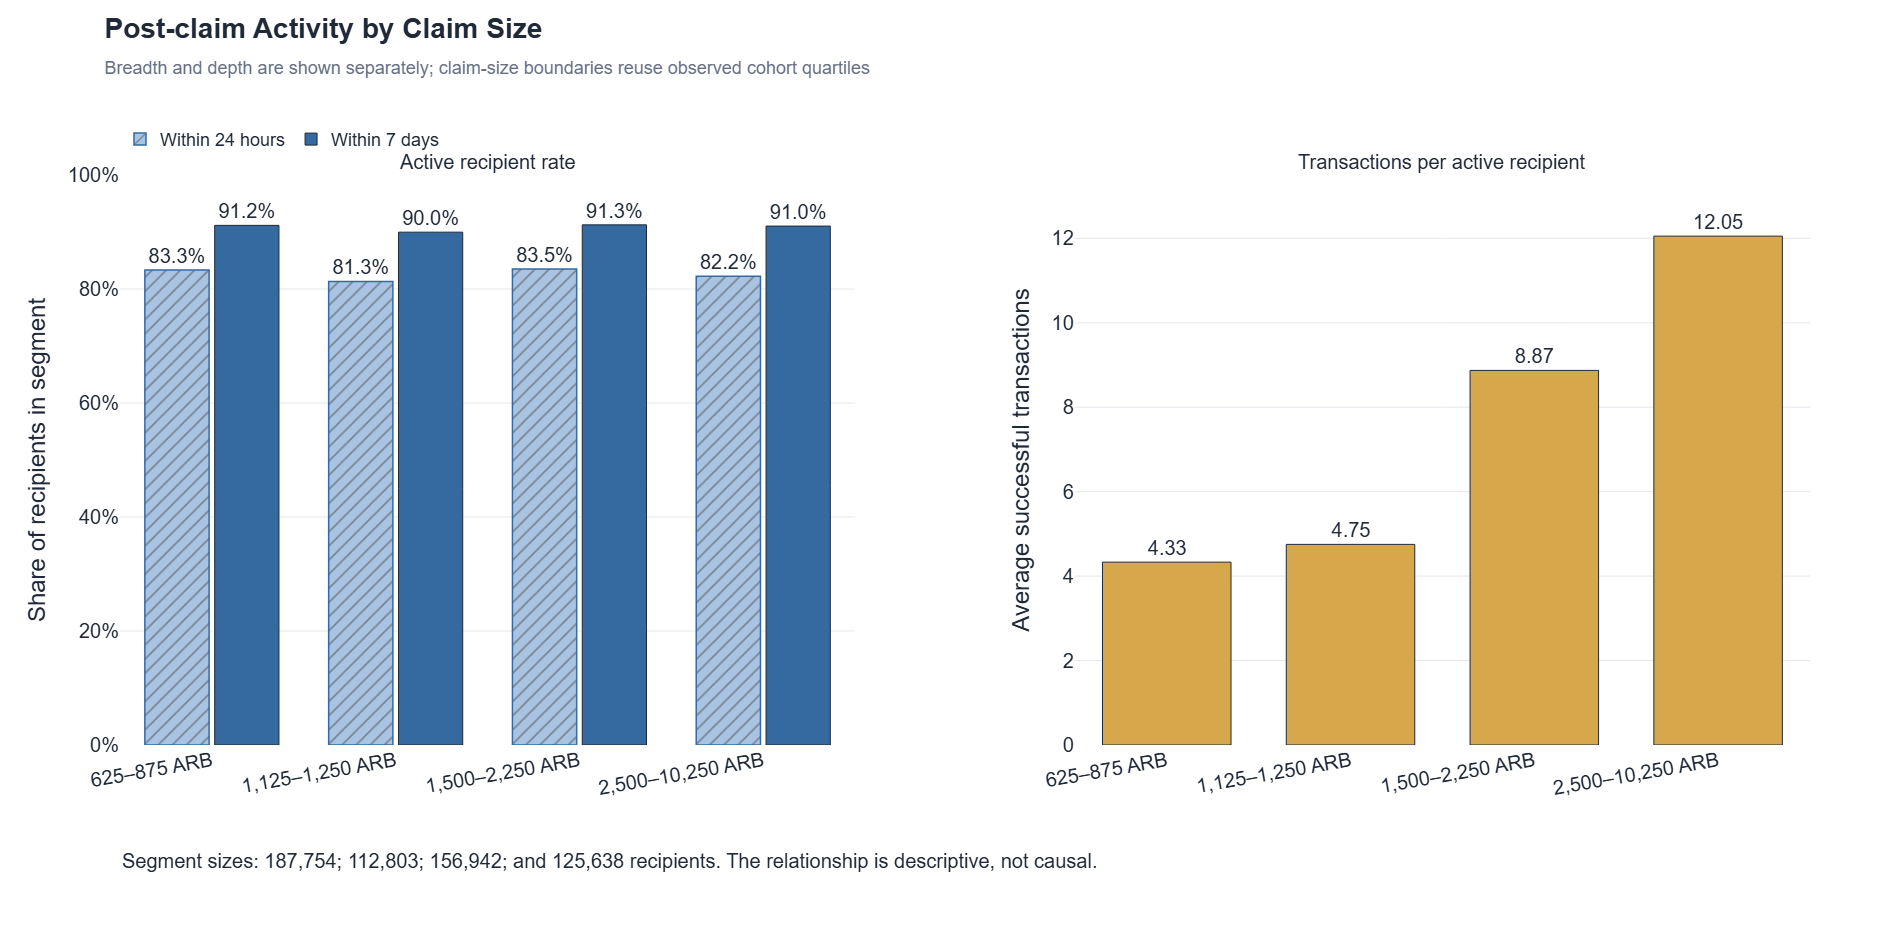

In [4]:
breadth_depth_fig = make_subplots(
    rows=1,
    cols=2,
    horizontal_spacing=0.13,
    subplot_titles=("Active recipient rate", "Transactions per active recipient"),
)
breadth_depth_fig.add_bar(
    name="Within 24 hours",
    x=segment_df["claim_size_segment"],
    y=segment_df["active_recipient_rate_24h"],
    marker=dict(
        color=COLORS["blue_light"],
        line=dict(color=COLORS["blue"], width=1.5),
        pattern=dict(shape="/", solidity=0.18),
    ),
    text=segment_df["active_recipient_rate_24h"].map(
        lambda value: f"{value:.1%}"
    ),
    textposition="outside",
    hovertemplate="%{x}<br>24 hours: %{y:.1%}<extra></extra>",
    row=1,
    col=1,
)
breadth_depth_fig.add_bar(
    name="Within 7 days",
    x=segment_df["claim_size_segment"],
    y=segment_df["active_recipient_rate_7d"],
    marker=dict(color=COLORS["blue"], line=dict(color=COLORS["ink"], width=1)),
    text=segment_df["active_recipient_rate_7d"].map(lambda value: f"{value:.1%}"),
    textposition="outside",
    hovertemplate="%{x}<br>7 days: %{y:.1%}<extra></extra>",
    row=1,
    col=1,
)
breadth_depth_fig.add_bar(
    name="Seven-day depth",
    x=segment_df["claim_size_segment"],
    y=segment_df["average_transactions_per_active_recipient_7d"],
    marker=dict(color=COLORS["gold"], line=dict(color=COLORS["ink"], width=1)),
    text=segment_df["average_transactions_per_active_recipient_7d"].map(
        lambda value: f"{value:.2f}"
    ),
    textposition="outside",
    hovertemplate="%{x}<br>7-day transactions per active recipient: %{y:.2f}<extra></extra>",
    showlegend=False,
    row=1,
    col=2,
)
apply_base_layout(
    breadth_depth_fig,
    "Post-claim Activity by Claim Size",
    "Breadth and depth are shown separately; claim-size boundaries reuse observed cohort quartiles",
    width=1900,
    height=950,
    bottom_note=(
        "Segment sizes: 187,754; 112,803; 156,942; and 125,638 recipients. "
        "The relationship is descriptive, not causal."
    ),
    margins=dict(l=120, r=90, t=175, b=205),
)
breadth_depth_fig.update_layout(
    barmode="group",
    bargap=0.24,
    bargroupgap=0.08,
    showlegend=True,
    legend=dict(
        orientation="h",
        x=0,
        xanchor="left",
        y=1.03,
        yanchor="bottom",
        font=dict(size=18),
    ),
)
breadth_depth_fig.update_yaxes(
    range=[0, 1],
    tickformat=".0%",
    title="Share of recipients in segment",
    showgrid=True,
    gridcolor=COLORS["grid"],
    zeroline=False,
    row=1,
    col=1,
)
breadth_depth_fig.update_yaxes(
    range=[0, 13.5],
    title="Average successful transactions",
    showgrid=True,
    gridcolor=COLORS["grid"],
    zeroline=False,
    row=1,
    col=2,
)
breadth_depth_fig.update_xaxes(title=None, showgrid=False, tickangle=-10)
breadth_depth_fig.update_annotations(font=dict(size=20, color=COLORS["ink"]))
_ = export_and_display(breadth_depth_fig, "05_post_claim_activity_by_claim_size")

### 3. Seven-day activity intensity

The final figure compares each intensity group's share of recipients with its share of all qualifying seven-day transaction rows. The two percentages use different explicit denominators.

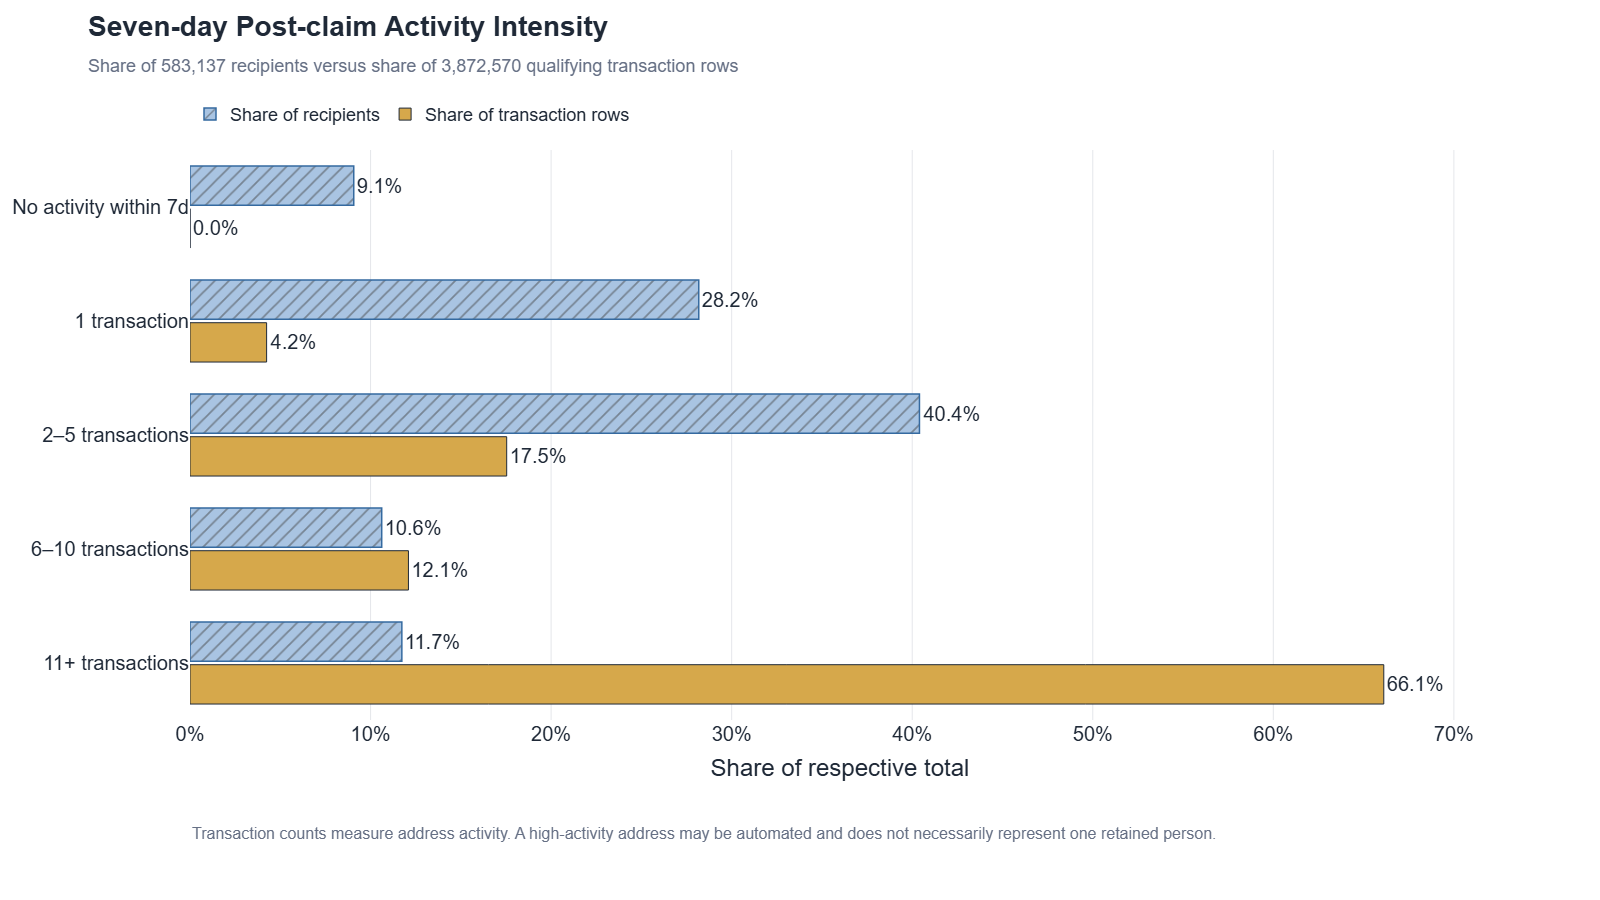

In [5]:
intensity_fig = go.Figure()
intensity_fig.add_bar(
    name="Share of recipients",
    x=intensity_df["recipient_share"],
    y=intensity_df["transaction_count_bucket"],
    orientation="h",
    marker=dict(
        color=COLORS["blue_light"],
        line=dict(color=COLORS["blue"], width=1.5),
        pattern=dict(shape="/", solidity=0.18),
    ),
    text=intensity_df["recipient_share"].map(lambda value: f"{value:.1%}"),
    textposition="outside",
    cliponaxis=False,
    hovertemplate="%{y}<br>Recipients: %{x:.1%}<extra></extra>",
)
intensity_fig.add_bar(
    name="Share of transaction rows",
    x=intensity_df["successful_transaction_share"],
    y=intensity_df["transaction_count_bucket"],
    orientation="h",
    marker=dict(color=COLORS["gold"], line=dict(color=COLORS["ink"], width=1)),
    text=intensity_df["successful_transaction_share"].map(
        lambda value: f"{value:.1%}"
    ),
    textposition="outside",
    cliponaxis=False,
    hovertemplate="%{y}<br>Transaction rows: %{x:.1%}<extra></extra>",
)
apply_base_layout(
    intensity_fig,
    "Seven-day Post-claim Activity Intensity",
    "Share of 583,137 recipients versus share of 3,872,570 qualifying transaction rows",
    bottom_note=(
        "Transaction counts measure address activity. A high-activity address may be automated "
        "and does not necessarily represent one retained person."
    ),
)
intensity_fig.update_layout(
    barmode="group",
    bargap=0.25,
    bargroupgap=0.08,
    showlegend=True,
    legend=dict(
        orientation="h",
        x=0,
        xanchor="left",
        y=1.03,
        yanchor="bottom",
        font=dict(size=18),
    ),
)
intensity_fig.update_xaxes(
    range=[0, 0.72],
    tickformat=".0%",
    title="Share of respective total",
    showgrid=True,
    gridcolor=COLORS["grid"],
    zeroline=False,
)
intensity_fig.update_yaxes(
    title=None,
    autorange="reversed",
    showgrid=False,
    automargin=True,
)
_ = export_and_display(intensity_fig, "06_post_claim_activity_intensity")

## Takeaways

1. Qualifying activity was widespread and fast: 82.8% of recipients were active within 24 hours, 90.9% within seven days, and 64.9% first became active within one hour.
2. Seven-day participation was similar across claim-size groups, ranging from 90.0% to 91.3%. Transaction depth differed more: average transactions per active recipient rose from 4.33 in the lowest segment to 12.05 in the highest.
3. Activity was concentrated in a high-frequency tail. The 11+ transaction group represented 11.7% of recipients and 66.1% of qualifying seven-day transaction rows.

### Interpretation limits

- A qualifying transaction can be a transfer, swap, approval, governance action, bridge interaction, automated action, or another top-level transaction. This notebook does not classify protocols or intent.
- Addresses are not people. Transaction counts can be influenced by automation and repeated actions.
- The claim-size relationship is descriptive and does not establish that larger allocations caused deeper activity.
- The metrics passed internal structural, cross-layer, bounded-subset, wallet-sample, and chart-data reconciliation. No independent public benchmark for the exact full-cohort activity metrics has been identified.